<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#CARB-Report-Results" data-toc-modified-id="CARB-Report-Results-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>CARB Report Results</a></span><ul class="toc-item"><li><span><a href="#Receptor-Locations-and-STILT-Days" data-toc-modified-id="Receptor-Locations-and-STILT-Days-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Receptor Locations and STILT Days</a></span></li><li><span><a href="#Correlations-between-Modeled-and-Observed" data-toc-modified-id="Correlations-between-Modeled-and-Observed-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Correlations between Modeled and Observed</a></span></li><li><span><a href="#Time-Series-for-Modeled-and-Observed" data-toc-modified-id="Time-Series-for-Modeled-and-Observed-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Time Series for Modeled and Observed</a></span></li><li><span><a href="#Receptor-Locations-with-FINNv2.5-or-WBSE-Emissions" data-toc-modified-id="Receptor-Locations-with-FINNv2.5-or-WBSE-Emissions-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Receptor Locations with FINNv2.5 or WBSE Emissions</a></span><ul class="toc-item"><li><span><a href="#Raster-plot-with-CA-Air-Basins" data-toc-modified-id="Raster-plot-with-CA-Air-Basins-1.4.1"><span class="toc-item-num">1.4.1&nbsp;&nbsp;</span>Raster plot with CA Air Basins</a></span></li><li><span><a href="#Difference-between-FINNv2.5-and-WBSE" data-toc-modified-id="Difference-between-FINNv2.5-and-WBSE-1.4.2"><span class="toc-item-num">1.4.2&nbsp;&nbsp;</span>Difference between FINNv2.5 and WBSE</a></span></li><li><span><a href="#Plot-Chico-and-San-Jose-footprints-with-Emissions" data-toc-modified-id="Plot-Chico-and-San-Jose-footprints-with-Emissions-1.4.3"><span class="toc-item-num">1.4.3&nbsp;&nbsp;</span>Plot Chico and San Jose footprints with Emissions</a></span></li></ul></li><li><span><a href="#STILT-HRRR-Wind-Fields" data-toc-modified-id="STILT-HRRR-Wind-Fields-1.5"><span class="toc-item-num">1.5&nbsp;&nbsp;</span>STILT HRRR Wind Fields</a></span></li><li><span><a href="#STILT-Mean-Footprints" data-toc-modified-id="STILT-Mean-Footprints-1.6"><span class="toc-item-num">1.6&nbsp;&nbsp;</span>STILT Mean Footprints</a></span></li></ul></li><li><span><a href="#EHS-414b-Results" data-toc-modified-id="EHS-414b-Results-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>EHS 414b Results</a></span></li></ul></div>

In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime
import openpyxl
# File management libraries
import os
from os import listdir
from os.path import isfile, join
import glob
# Plotting libraries
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from matplotlib import pyplot as plt, cm
import matplotlib.colors as mcolors
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
# Statistics library
from scipy import stats
import statsmodels.api as sm
# Raster libraries
import rioxarray as rxr
import xarray as xr
import rasterio
from rasterio import plot
# Geographic plotting libraries
from shapely.geometry import mapping

In [2]:
mypath = '/Users/clairebekker/Library/CloudStorage/Box-Box/WBSE_Emissions/FINN_WBSE_72hrconc/'

In [3]:
directory1 = '/Volumes/External drive/Summer_2022/site_selection/'

In [4]:
directory2= '/Users/clairebekker/Library/CloudStorage/Box-Box/WBSE_emissions/'

In [5]:
directory3= '/Users/clairebekker/Library/CloudStorage/Box-Box/WBSE_emissions/FINN_WBSE_emiss_figures/'

## Receptor Locations and STILT Days

In [7]:
# Get the receptor locations and their names
receptor_locations = pd.read_csv(directory1 + 'SELECTED_improve_aqs_distances.csv')
receptor_locations_newCMAQ= pd.read_csv(directory1+'IMPROVE+AQS_selected_airbasins2018.csv')

# Sort the receptor locations by the 2018 Mean Annual CMAQ, descending order 
receptor_locations=receptor_locations.merge(receptor_locations_newCMAQ, how='left', on='SiteName')
receptor_locations=receptor_locations.sort_values(by=['2018 Mean July-Sept Fire PM'], ascending = False).reset_index()

# Get the list of receptors by air basin WBSE emissions 
receptors_table=pd.read_excel(directory3+'Table1.xlsx')

In [8]:
# Combine receptors table with latitude and longitude of receptors 
receptors_lat_long=receptor_locations[['Latitude_x', 'Longitude_x', 'SiteName']]
receptors_table2= receptors_table.merge(receptors_lat_long, how='inner', left_on=['Receptor(s)  Names'], right_on=['SiteName'])

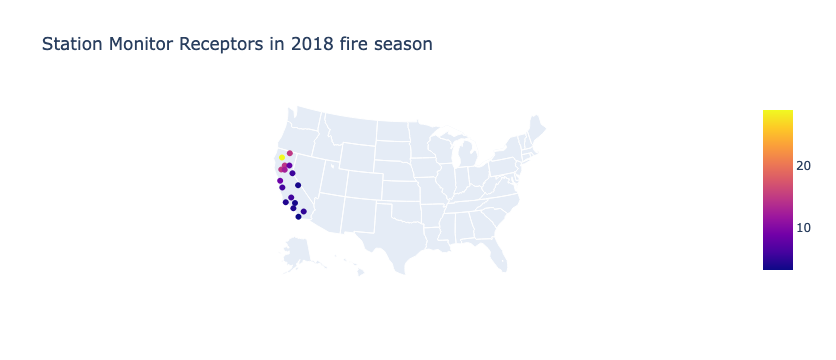

In [9]:
# Create map of receptor locations
fig1=px.scatter_geo(receptor_locations, 
                    lat='Latitude_x', lon='Longitude_x', 
                    hover_name='SiteName', 
                    hover_data= ['# Measurements in fire season_x', '2018 Mean July-Sept Fire PM'],
                    color= '2018 Mean July-Sept Fire PM', 
                    color_continuous_scale=px.colors.sequential.OrRd)
fig2=go.Figure(data=fig1.data)
fig2.update_layout(title = 'Station Monitor Receptors in 2018 fire season',geo_scope='usa')
fig2.show()

### Correlations between Modeled and Observed

In [10]:
# Get all of the csv files with the modeled and observed concentration results
from os import listdir
from os.path import isfile, join
mypath2='/Users/clairebekker/Library/CloudStorage/Box-Box/WBSE_Emissions/FINN_WBSE_72hrconc/'
onlyfiles = [f for f in listdir(mypath2) if isfile(join(mypath2, f)) & f.endswith("wildfire_conc_2018days_72.csv")]

In [11]:
# Create dictionary with each csv file and make dataframe for concentration results 
d= {}
receptor_names=[]
for x in range(0, len(onlyfiles)): 
    text = onlyfiles[x].split("_")
    receptor_names.append(receptors_table2['Receptor(s)  Names'][np.around(receptors_table2['Longitude_x'],decimals=5).astype(str)==text[0]]) 
    recept_name_new= receptor_names[x].iloc[0]
    d['{0}'.format(recept_name_new)]= pd.read_csv(mypath2 + onlyfiles[x])
    data = pd.DataFrame(d['{0}'.format(recept_name_new)])
    obs_column = [col for col in data.columns if col in ['Arithmetic.Mean', 'PM2.5']]
    data['Station Monitor'] = data[obs_column]
    d['{0}'.format(recept_name_new)]=data

In [12]:
receptors_table2['Receptor(s)  Names']

0                              Cortina Indian Rancheria
1                                     Chico-East Avenue
2                                             Yuba City
3                                Quincy-N Church Street
4                                             Lava Beds
5                               Trinity National Forest
6                        Long Beach-Route 710 Near Road
7                                    San Jose - Jackson
8     White Mountain Research Center - Owens Valley Lab
9                                Bakersfield-California
10               El Cajon - Lexington Elementary School
11                                               Goleta
12                                            Pinnacles
13                         Lake Tahoe Community College
14                                                Indio
15                            Lancaster-Division Street
Name: Receptor(s)  Names, dtype: object

In [13]:
# Calculate mean STILT-FINN and STILT-WBSE Smoke PM2.5 during fire season 
allfiles= [f for f in listdir(mypath2) if isfile(join(mypath2, f)) & f.endswith("wildfire_conc_2018days_72.csv")]
# Dictionary with csv file for all fire days in 2018
d_all= {}
receptor_names=[]
for x in range(0, len(onlyfiles)): 
    text = allfiles[x].split("_")
    receptor_names.append(receptors_table2['Receptor(s)  Names'][np.around(receptors_table2['Longitude_x'],decimals=5).astype(str)==text[0]]) 
    recept_name_new= receptor_names[x].iloc[0]
    d_all['{0}'.format(recept_name_new)]= pd.read_csv(mypath2 + allfiles[x])
# Create new dataframe for mean smoke PM2.5 
receptor_smoke_pm= pd.DataFrame(columns=['receptor name', 'STILT-FINNv2.5 mean', 'STILT-WBSE mean'])
for y in range(0,len(list(d.keys()))):
    recept_name= receptors_table2['Receptor(s)  Names'][y]
    receptor_df= pd.DataFrame(d_all['{0}'.format(recept_name)])
    STILT_FINN_mean = receptor_df['PM25_FINN'].mean()
    STILT_WBSE_mean=receptor_df['PM25_WBSE'].mean()
    receptor_smoke_pm.loc[len(receptor_smoke_pm.index)] = [recept_name, STILT_FINN_mean, STILT_WBSE_mean] 

In [21]:
receptor_smoke_pm.to_csv(mypath+'receptor_mean_smoke_pm.csv')

In [14]:
# Iterate through receptors and get data into larger dataframe
data_frame = pd.DataFrame(columns=['Time_PST', 'Station Monitor', 'PM25_FINN', 'PM25_WBSE'])
for z in range(0,16): 
    recept_name= receptors_table2['Receptor(s)  Names'][z]
    data= pd.DataFrame(d['{0}'.format(recept_name)])
    data_frame= pd.concat([data_frame, data[['Time_PST', 'Station Monitor', 'PM25_FINN', 'PM25_WBSE']]], axis=0, ignore_index=True)

/var/folders/bt/zz9p33b12m55w8szgpmyprmr0000gn/T/ipykernel_50423/949483884.py:6: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [30]:
data_frame

,Time_PST,Station Monitor,PM25_FINN,PM25_WBSE
0,2018-07-01,10.0,0.046009,0.012105
1,2018-07-02,24.5,1.187924,8.407689
2,2018-07-03,13.4,3.698126,23.134460
3,2018-07-04,49.6,1.369649,6.485857
4,2018-07-05,18.8,0.387809,2.957491
...,...,...,...,...
1048,2018-09-26,8.8,0.024479,0.001976
1049,2018-09-27,8.0,0.026276,0.000000
1050,2018-09-28,8.4,0.018031,0.000000
1051,2018-09-29,6.5,0.001435,0.000000


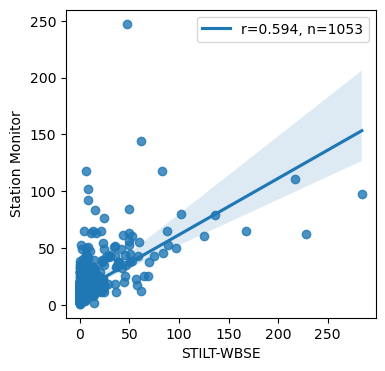

In [17]:
# Correlation plot with all data from receptors 
fig, axs= plt.subplots(figsize=(4,4))
slope, intercept, r_value, p_value, std_err = stats.linregress(data_frame['PM25_WBSE'],data_frame['Station Monitor'])
total_list_vals = r_value, p_value, data_frame.shape[0]
plot=sns.regplot(x="PM25_WBSE", y="Station Monitor", data=data_frame, ax=axs, 
    line_kws={'label':"r={0:.3f}, n={1}".format(r_value, data_frame.shape[0])})
axs.legend()
fig.savefig(mypath+'WBSE_correlation_plot.png', dpi=1000, bbox_inches='tight', pad_inches=0.25)

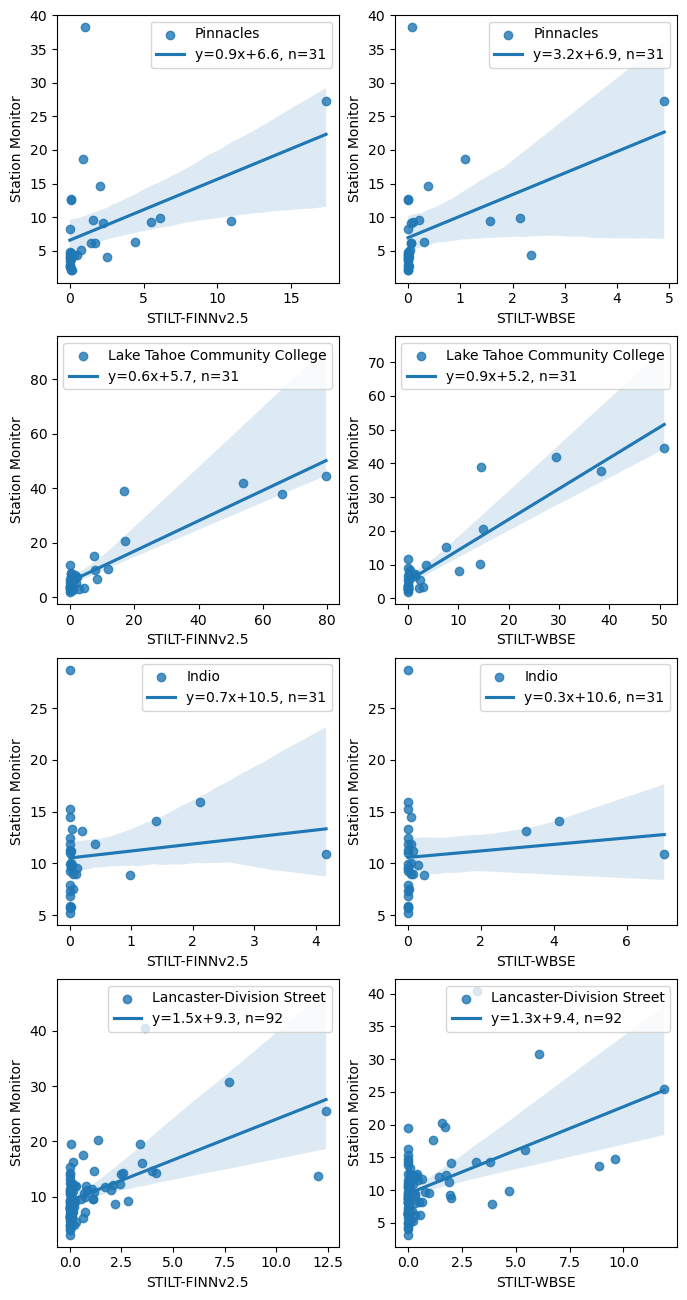

In [80]:
# Correlation plots and statistics (r and p values)
fig, axs= plt.subplots(nrows=4, ncols=2, figsize=(8,16))
#fig.suptitle("Correlations between Modeled and Observed PM2.5 Concentrations")
#stats_num=[]
#stats_num2=[]
count2= 0 
for y in range(12, 16): 
    count=0
    recept_name=receptors_table2['Receptor(s)  Names'][y]
    data= pd.DataFrame(d['{0}'.format(recept_name)])
    slope, intercept, r_value, p_value, std_err = stats.linregress(data['PM25_FINN'],data['Station Monitor'])
    slope2, intercept2, r_value2, p_value2, std_err = stats.linregress(data['PM25_WBSE'],data['Station Monitor'])
    #list_vals = recept_name, r_value, p_value, data.shape[0]
    #list_vals2= recept_name, r_value2, p_value2, data.shape[0]
    #stats_num.append(list_vals)
    #stats_num2.append(list_vals2)
    plot=sns.regplot(x="PM25_FINN", y="Station Monitor", data=data, ax=axs[count2, 0], label= recept_name[0:31],
             line_kws={'label':"y={0:.1f}x+{1:.1f}, n={2}".format(slope,intercept, data.shape[0])})
    plot2=sns.regplot(x="PM25_WBSE", y="Station Monitor", data=data, ax=axs[count2, 1], label= recept_name[0:31], 
             line_kws={'label':"y={0:.1f}x+{1:.1f}, n={2}".format(slope2,intercept2, data.shape[0])})
    axs[count2, 0].legend()
    axs[count2, 1].legend()
    count2 = count2 + 1
fig.savefig(mypath2+'72hr_figures/correlations4.pdf',bbox_inches='tight', pad_inches=0.25)
#stats_num_df = pd.DataFrame(stats_num, columns=['Site Name', 'r value', 'p value', 'n'])
#stats_num_df2 = pd.DataFrame(stats_num2, columns=['Site Name', 'r value', 'p value', 'n'])

In [24]:
# Write the dataframe to csv 
stats_num_df.to_csv(mypath2+'FINN_correlations_stats.csv')
stats_num_df2.to_csv(mypath2+'WBSE_correlations_stats.csv')

In [18]:
# Get correlation stats by receptor 
WBSE_stats_df= pd.read_csv(directory2+'FINN_WBSE_72hrconc/72hr_figures/WBSE_correlations_stats.csv')
FINN_stats_df= pd.read_csv(directory2+'FINN_WBSE_72hrconc/72hr_figures/FINN_correlations_stats.csv')

In [20]:
# Merge FINN and WBSE correlation stats
receptors_merged=pd.merge(WBSE_stats_df, FINN_stats_df, on='Site Name', how='outer', suffixes=['_WBSE', '_FINN'])

In [26]:
# Merge FINN and WBSE correlation stats with receptor location information 
receptors_merged=pd.merge(receptors_merged, receptors_table2, left_on='Site Name', right_on='Receptor(s)  Names')

In [28]:
# Save final Table with FINNv2.5 and WBSE correlations and emissions data
receptors_merged.to_csv(directory2 + 'FINN_WBSE_72hrconc/72hr_figures/all_correlation_stats.csv')

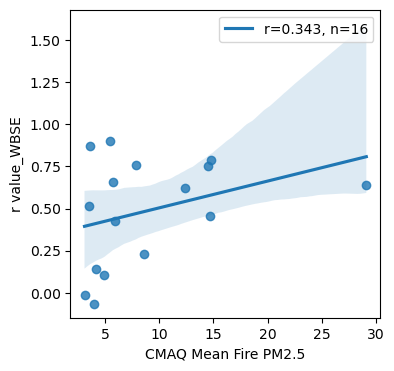

In [37]:
# Plot the mean 2018 CMAQ values against the correlation coefficients  
fig, axs= plt.subplots(figsize=(4,4))
slope, intercept, r_value, p_value, std_err = stats.linregress(receptors_merged['CMAQ Mean Fire PM2.5'],receptors_merged['r value_WBSE'])
plot=sns.regplot(x="CMAQ Mean Fire PM2.5", y="r value_WBSE", data=receptors_merged, ax=axs, 
    line_kws={'label':"r={0:.3f}, n={1}".format(r_value, receptors_merged.shape[0])})
axs.legend()
fig.savefig(mypath+'72hr_figures/WBSE_CMAQ_correlations.png', bbox_inches='tight', pad_inches=0.25)

### Time Series for Modeled and Observed

In [34]:
data

,Time_PST,PM25_FINN,PM25_WBSE,location,Arithmetic.Mean,Station Monitor
0,2018-07-01,0.140345,0.064878,-118.13051_34.669739,7.3,7.3
1,2018-07-02,0.212108,0.495606,-118.13051_34.669739,8.2,8.2
2,2018-07-03,0.754121,4.669523,-118.13051_34.669739,9.9,9.9
3,2018-07-04,0.088232,0.629409,-118.13051_34.669739,8.2,8.2
4,2018-07-05,0.006431,0.046608,-118.13051_34.669739,7.1,7.1
...,...,...,...,...,...,...
87,2018-09-26,0.024479,0.001976,-118.13051_34.669739,8.8,8.8
88,2018-09-27,0.026276,0.000000,-118.13051_34.669739,8.0,8.0
89,2018-09-28,0.018031,0.000000,-118.13051_34.669739,8.4,8.4
90,2018-09-29,0.001435,0.000000,-118.13051_34.669739,6.5,6.5


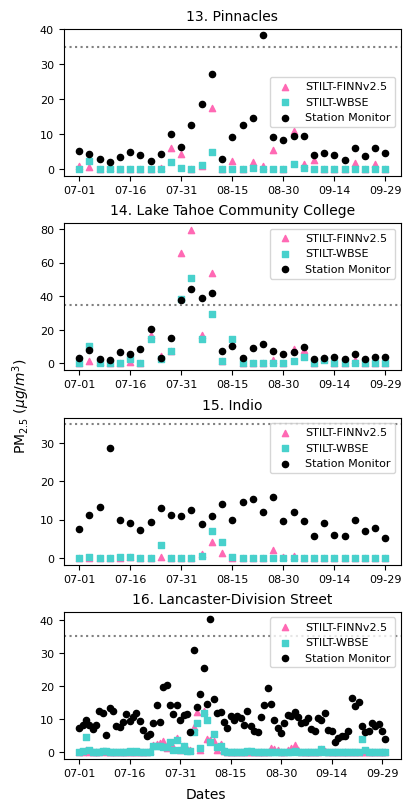

In [20]:
# Plot time series of PM2.5 for receptors
fig, axs= plt.subplots(nrows=4, ncols=1, figsize=(4,8), constrained_layout=True)
count2= 0 
for y in range(12,16): 
    recept_name = recept_name=receptors_table2['Receptor(s)  Names'][y]
    data= pd.DataFrame(d['{0}'.format(recept_name)])
    data['Time_PST']= pd.to_datetime(data['Time_PST'])
    data['MM-DD'] = data['Time_PST'].dt.strftime('%m-%d')
    axs[count2].xaxis.set_major_locator(plt.MaxNLocator(7))
    axs[count2].scatter(data['MM-DD'], data['PM25_FINN'], marker='^', c="hotpink", label= "STILT-FINNv2.5", s=20)
    axs[count2].scatter(data['MM-DD'], data['PM25_WBSE'], marker='s', c="mediumturquoise", label= "STILT-WBSE", s=20)
    axs[count2].scatter(data['MM-DD'], data['Station Monitor'], marker='o', c="black", label= "Station Monitor", s=20)
    # specifying horizontal line type 
    axs[count2].axhline(y = 35, color = 'gray', linestyle = 'dotted') 
    axs[count2].legend(fontsize=8)
    axs[count2].tick_params(labelsize=8)
    axs[count2].set_title(str(y+1)+". "+str(recept_name)[0:31], fontsize=10)
    count2=count2+1
fig.supxlabel('Dates', fontsize=10)
fig.supylabel(r'PM$_{2.5}$ ($µg/m^3$)', fontsize=10)
fig.savefig(mypath2+'72hr_figures/timeseries4.png', bbox_inches='tight', pad_inches=0.25, dpi=900)
plt.show()

#### Time Series for all ABL iterations

In [60]:
mypath1='/Users/clairebekker/Library/CloudStorage/Box-Box/WBSE_Emissions/out_abl_test/'
onlyfiles1 = [f for f in listdir(mypath1) if isfile(join(mypath1, f)) & f.endswith("2.csv")]

In [61]:
mypath2='/Users/clairebekker/Library/CloudStorage/Box-Box/WBSE_Emissions/FINN_WBSE_abl/'
onlyfiles2 = [f for f in listdir(mypath2) if isfile(join(mypath2, f)) & f.endswith("abl.csv")]

In [62]:
mypath3='/Users/clairebekker/Library/CloudStorage/Box-Box/WBSE_Emissions/FINN_WBSE_24hrconc/'
onlyfiles3 = [f for f in listdir(mypath3) if isfile(join(mypath3, f)) & f.startswith(('-121.894898', '-121.84047'))  & f.endswith("2.csv")]

In [63]:
mypath4= '/Users/clairebekker/Library/CloudStorage/Box-Box/WBSE_Emissions/FINN_WBSE_72hrconc/Chico_San_Jose/'
onlyfiles4 = [f for f in listdir(mypath4) if isfile(join(mypath4, f))  & f.endswith("_72.csv")]

In [64]:
# Create dictionary with each csv file and make dataframe for concentration results 
abl_2000 = {}
abl_1PBL= {}
abl_05PBL={}
back_72 = {}
dict_list = [abl_2000, abl_1PBL, abl_05PBL]
receptor_names=['Chico-East Avenue', 'San Jose - Jackson']
for x in range(0, len(onlyfiles1)): 
    text1 = onlyfiles1[x].split("_")
    recept_name_new1= (receptor_locations['SiteName'][np.around(receptor_locations['Longitude_x'],decimals=6).astype(str)==text1[0]]).iloc[0]
    text2 = onlyfiles2[x].split("_")
    recept_name_new2=(receptor_locations['SiteName'][np.around(receptor_locations['Longitude_x'],decimals=6).astype(str)==text2[0]]).iloc[0] 
    text3 = onlyfiles3[x].split("_")
    recept_name_new3=(receptor_locations['SiteName'][np.around(receptor_locations['Longitude_x'],decimals=6).astype(str)==text3[0]]).iloc[0]
    text4 = onlyfiles4[x].split("_")
    recept_name_new4=(receptor_locations['SiteName'][np.around(receptor_locations['Longitude_x'],decimals=6).astype(str)==text4[0]]).iloc[0]
    abl_2000['{0}'.format(recept_name_new1)]= pd.read_csv(mypath1 + onlyfiles1[x])
    abl_1PBL['{0}'.format(recept_name_new2)]= pd.read_csv(mypath2 + onlyfiles2[x])
    abl_05PBL['{0}'.format(recept_name_new3)]= pd.read_csv(mypath3 + onlyfiles3[x])
    back_72['{0}'.format(recept_name_new4)]= pd.read_csv(mypath4 + onlyfiles4[x])

/var/folders/bt/zz9p33b12m55w8szgpmyprmr0000gn/T/ipykernel_15821/3802659646.py:13: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/var/folders/bt/zz9p33b12m55w8szgpmyprmr0000gn/T/ipykernel_15821/3802659646.py:13: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



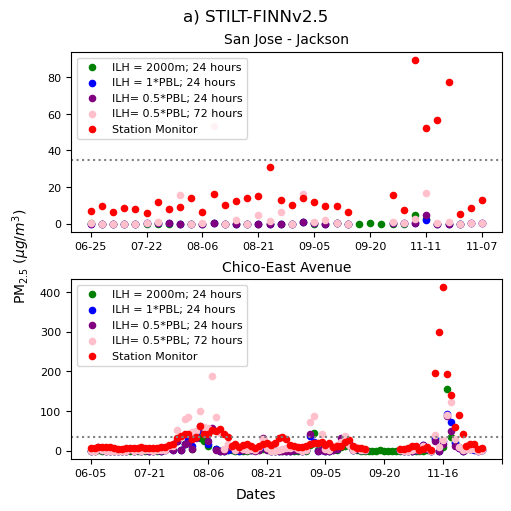

In [182]:
# Plot time series of PM2.5 for San Jose and Chico
fig, axs= plt.subplots(nrows=2, ncols=1, figsize=(5,5), constrained_layout=True)
recept_names =['San Jose - Jackson', 'Chico-East Avenue']
#stats_num=[]
count2= 0 
for y in range(0, 2): 
    recept_name= recept_names[y]
    data1= pd.DataFrame(abl_2000['{0}'.format(recept_name)])
    data2= pd.DataFrame(abl_1PBL['{0}'.format(recept_name)])
    data3= pd.DataFrame(abl_05PBL['{0}'.format(recept_name)])
    data4 = pd.DataFrame(back_72['{0}'.format(recept_name)])
    for data in [data1, data2, data3, data4]:
        data['Time_UTC']= pd.to_datetime(data['Time_UTC'])
        data['MM-DD'] = data['Time_UTC'].dt.strftime('%m-%d')
    axs[y].xaxis.set_major_locator(plt.MaxNLocator(8))
    axs[y].scatter(data1['MM-DD'], data1['PM25_FINN'], c="green", label= "ILH = 2000m; 24 hours", s=20)
    axs[y].scatter(data2['MM-DD'], data2['PM25_FINN'], c="blue", label= "ILH = 1*PBL; 24 hours", s=20)
    axs[y].scatter(data3['MM-DD'], data3['PM25_FINN'], c="purple", label= "ILH= 0.5*PBL; 24 hours", s=20)
    axs[y].scatter(data4['MM-DD'], data4['PM25_FINN'], c="pink", label= "ILH= 0.5*PBL; 72 hours", s=20)
    axs[y].scatter(data3['MM-DD'], data3['Arithmetic.Mean'], c="red", label= "Station Monitor", s=20)
     # specifying horizontal line type 
    axs[y].axhline(y = 35, color = 'gray', linestyle = 'dotted') 
    axs[y].legend(fontsize=8)
    axs[y].tick_params(labelsize=8)
    axs[y].set_title(str(recept_name), fontsize=10)
    count2=count2+1
fig.supxlabel('Dates', fontsize=10)
fig.supylabel(r'PM$_{2.5}$ ($µg/m^3$)', fontsize=10)
fig.suptitle("a) STILT-FINNv2.5", fontsize=12)
fig.savefig(directory2+'sensitivity_timeseries_FINN.pdf', bbox_inches='tight', pad_inches=0.25)
plt.show()

### Bland-Altman Plots

In [157]:
import matplotlib.pyplot as plt
import numpy as np
import pdb
from numpy.random import random

def bland_altman_plot(data1, data2, *args, **kwargs):
    data1     = np.asarray(data1)
    data2     = np.asarray(data2)
    mean      = np.mean([data1, data2], axis=0)
    diff      = data1 - data2                   # Difference between data1 and data2
    md        = np.mean(diff)                   # Mean of the difference
    sd        = np.std(diff, axis=0)            # Standard deviation of the difference
    CI_low    = md - 1.96*sd
    CI_high   = md + 1.96*sd
    return md, sd, mean, diff, CI_low, CI_high

/var/folders/bt/zz9p33b12m55w8szgpmyprmr0000gn/T/ipykernel_15821/4157041689.py:28: UserWarning:

This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.



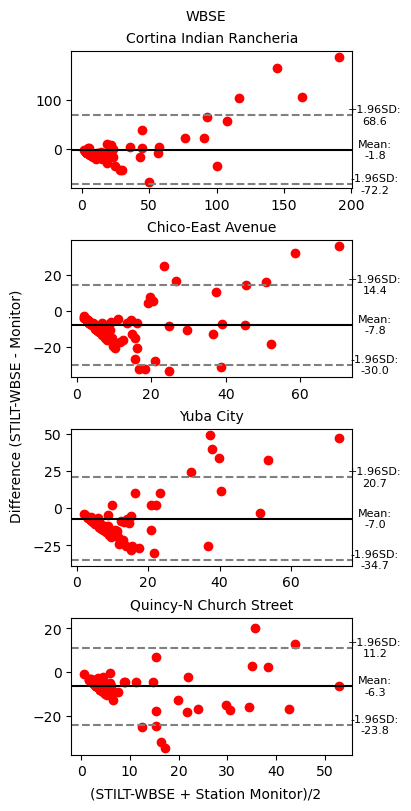

In [190]:
import statsmodels.api as sm
fig, axs= plt.subplots(nrows=4, ncols=1, figsize=(4,8), constrained_layout=True)
count2=0
for y in range(0,4): 
    recept_name = recept_name=receptors_table2['Receptor(s)  Names'][y]
    data= pd.DataFrame(d['{0}'.format(recept_name)])
    #sm.graphics.mean_diff_plot(data['PM25_FINN'], data['PM25_WBSE'], ax = axs[y])
    md, sd, mean, diff, CI_low, CI_high = bland_altman_plot(data['PM25_WBSE'], data['Station Monitor'])
    axs[count2].scatter(mean, diff, color='red')
    axs[count2].axhline(md, color='black', linestyle='-')
    axs[count2].axhline(md + 1.96*sd, color='gray', linestyle='--')
    axs[count2].axhline(md - 1.96*sd, color='gray', linestyle='--')
    plt.ylim(md - 3.5*sd, md + 3.5*sd)
    xOutPlot = np.min(mean) + (np.max(mean)-np.min(mean))*1.14
    axs[count2].text(xOutPlot, md - 1.96*sd, 
        r'-1.96SD:' + "\n" + "%.1f" % CI_low, 
        ha = "center",
        va = "center", fontsize=8)
    axs[count2].text(xOutPlot, md + 1.96*sd, 
        r'+1.96SD:' + "\n" + "%.1f" % CI_high, 
        ha = "center",
        va = "center", fontsize=8)
    axs[count2].text(xOutPlot, md, 
        r'Mean:' + "\n" + "%.1f" % md, 
        ha = "center",
        va = "center", fontsize=8)
    axs[count2].set_title(str(recept_name), fontsize=10)
    plt.subplots_adjust(left=0.3)
    count2=count2+1
fig.suptitle('WBSE', fontsize=10)
fig.supxlabel('(STILT-WBSE + Station Monitor)/2', fontsize=10)
fig.supylabel('Difference (STILT-WBSE - Monitor)', fontsize=10) 
fig.savefig(directory2+'FINN_WBSE_72hrconc/72hr_figures/WBSE_bland_altman_1.pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

## Receptor Locations with FINNv2.5 or WBSE Emissions

In [29]:
# Load the raster files with summed emissions by day
directory2= '/Users/clairebekker/Library/CloudStorage/Box-Box/WBSE_emissions/'
allfires_FINN_plot=rxr.open_rasterio(directory2+"Emissions_processing/summed_finnv2.5.tif").squeeze()
allfires_WBSE = rxr.open_rasterio(directory2+'Emissions_processing/summed_allfires_WBSE.tif').squeeze()

In [30]:
# Add shapefile with CA air basins
air_basins= '/Volumes/External drive/Summer_2022/site_selection/CA_air_basins/arb_california_airbasins_aligned_03.shp'

In [31]:
# Read in the air basins shapefile with geopandas
CA_air_basins= gpd.read_file('/Volumes/External drive/Summer_2022/site_selection/CA_air_basins/arb_california_airbasins_aligned_03.shp')
# Reproject the shapefile to the raster crs 
CA_airbasins_proj= CA_air_basins.to_crs(allfires_FINN_plot.rio.crs)

In [32]:
# Drop duplicate labels for air basins and add basin numbers
CA_airbasins_labels=CA_airbasins_proj.drop_duplicates(subset=['BASIN_NAME']).reset_index()
CA_airbasins_labels['Basin_num']= range(1,16)
#CA_airbasins_labels.to_file(directory1 + 'CA_airbasins_labels.shp')

### Raster plot with CA Air Basins 

In [33]:
receptors_table2['Index']= range(1,17)

##### Difference between FINNv2.5 and WBSE

In [34]:
allfires_FINN_plot=allfires_FINN_plot[0:315,:]

In [82]:
#interpolate allfires_FINN to allfires_WBSE
allfires_WBSE = allfires_WBSE.interp(x=allfires_FINN_plot["x"], y=allfires_FINN_plot["y"])

In [83]:
# Find the difference between FINNv2.5 and WBSE summed annual emissions
emis_difference= allfires_FINN_plot - allfires_WBSE

In [84]:
# Clip the difference raster by the California shapefile
ca_boundary = gpd.read_file(directory2 + 'ca-state-boundary/CA_State_TIGER2016.shp')
ca_boundary=ca_boundary.to_crs(emis_difference.rio.crs)
emis_diff_clipped = emis_difference.rio.clip(ca_boundary.geometry.apply(mapping))
allfires_FINN_plot = allfires_FINN_plot.rio.clip(ca_boundary.geometry.apply(mapping))

In [85]:
# New color map for the sensitivities in log form
emissions_color_map = mpl.colors.ListedColormap(['yellow', 'orange', 'orangered', 'red', 'brown']).with_extremes(under='white')
bounds = [7e1, 7e2, 7e3, 7e4, 7e5, 7e6]
norm= mpl.colors.BoundaryNorm(bounds, ncolors=5)

In [86]:
CA_airbasins_labels.geometry[1].centroid.coords[0][0]

-121.44331950673632

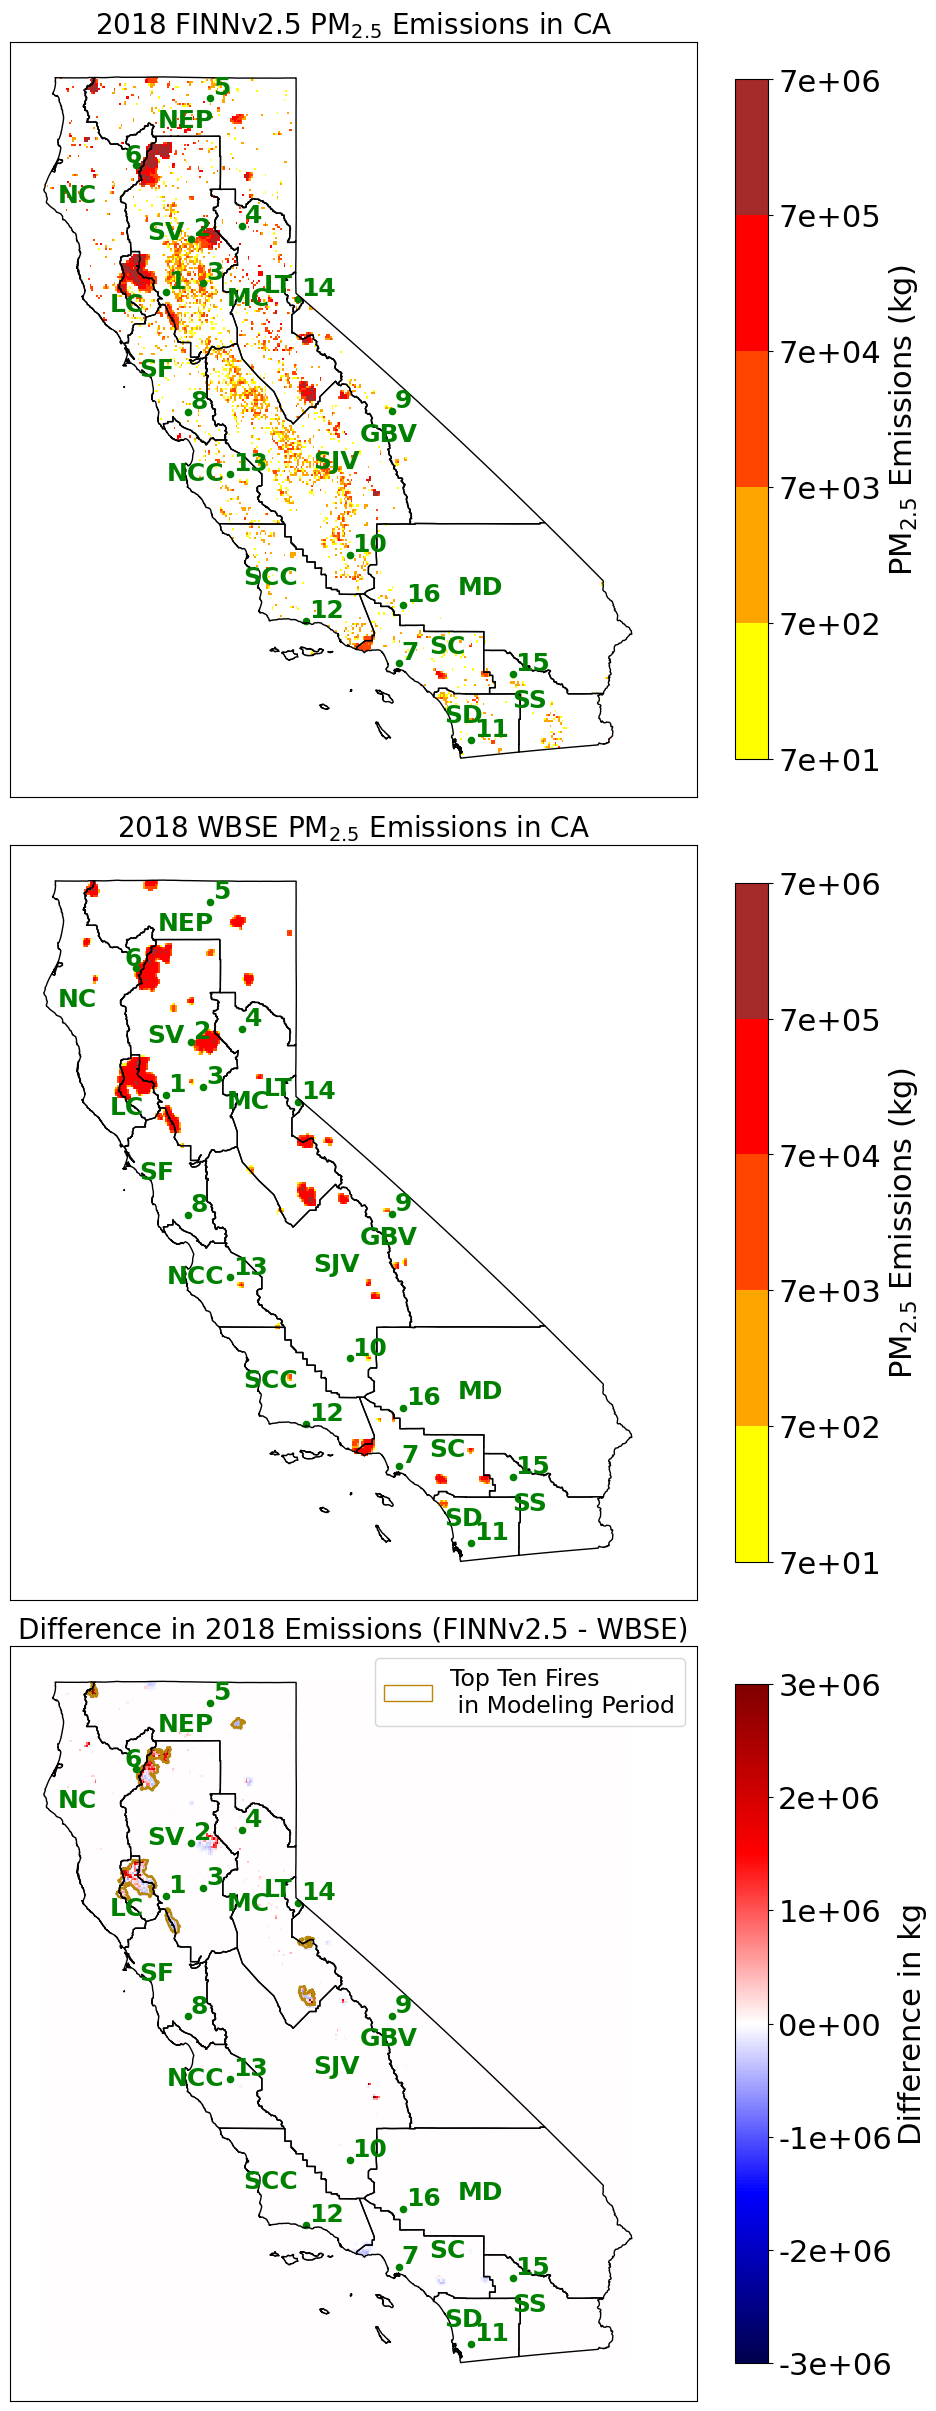

In [94]:
# Plot the air basins with the receptor locations and FINNv2.5 emissions
f, ax = plt.subplots(nrows=3, ncols=1, figsize=(10,24),constrained_layout=True)

# plot the FINNv2.5 layer
finn=allfires_FINN_plot[:,:].plot.imshow(ax=ax[0], cmap=emissions_color_map, norm=norm, add_colorbar=False)
ax[0].set_title('2018 FINNv2.5 PM$_{2.5}$ Emissions in CA', fontsize=20)
cbar = plt.colorbar(wbse, ax=ax[0], format='%.0e', shrink=0.9)
cbar.ax.tick_params(labelsize=22)
cbar.set_label('PM$_{2.5}$ Emissions (kg)',fontsize=22)

# Plot the WBSE layer
wbse=allfires_WBSE[:,:].plot.imshow(ax=ax[1], cmap=emissions_color_map, norm=norm, add_colorbar=False)
ax[1].set_title('2018 WBSE PM$_{2.5}$ Emissions in CA', fontsize=20)
cbar = plt.colorbar(wbse, ax=ax[1], format='%.0e', shrink=0.9)
cbar.ax.tick_params(labelsize=22)
cbar.set_label('PM$_{2.5}$ Emissions (kg)',fontsize=22)
# Plot the difference between the WBSE and FINNv2.5 
color_map2 = plt.get_cmap('seismic')
em3=emis_difference.plot(ax=ax[2], cmap=color_map2,vmin=-3e6, vmax=3e6,add_colorbar=False)
ax[2].set_title('Difference in 2018 Emissions (FINNv2.5 - WBSE)', fontsize=20)
cbar = plt.colorbar(em3, format='%.0e', shrink=0.9)
cbar.ax.tick_params(labelsize=22)
cbar.set_label('Difference in kg',fontsize=22)

# MTBS Fires 
# Get the MTBS shapefiles 
shapefile_path = directory2 + 'mtbs/2018/'
shapefile_files = [s for s in listdir(shapefile_path) if isfile(join(shapefile_path, s)) & s.endswith("bndy.shp")]
# Get the names of top 10 fires
list_names=['ca3924012311020180727', 'ca4065012263020180723', 'ca3765211988120180713', 'ca4094312242720180905', 'ca3881012220020180630',
'ca4089112222820180809', 'ca4195612355120180715', 'ca3834911992920180801', 'ca3906012314020180727', 'ca4139512105720180815']
pmarks=[]
for x in range(0, 10):
    # Find the file that matches the current fire MTBS code name
    shapefile_file=[s for s in listdir(shapefile_path) if isfile(join(shapefile_path, s)) & s.endswith("bndy.shp") & s.startswith(list_names[x])][0]
    # Read the input shapefile
    input_shapefile = shapefile_path + shapefile_file
    shapefile = gpd.read_file(input_shapefile)
    # Reproject the shapefile to the raster crs 
    shapefile= shapefile.to_crs(4326)
    # Plot the shapefile fire perimeter
    shapefile_plot=shapefile.plot(ax=ax[2], facecolor="none", edgecolor='darkgoldenrod', zorder=1, linewidth=1.5)
pmarks.append(Patch(facecolor="none", edgecolor='darkgoldenrod', label='Top Ten Fires \n in Modeling Period'))
handles, _ = ax[2].get_legend_handles_labels()
ax[2].legend(handles=[*handles,*pmarks], fontsize=17)

# Add receptor and air basin information 
for y in range(0,3):
    # Plot the receptor locations
    ax[y].scatter(receptors_table2['Longitude_x'], receptors_table2['Latitude_x'], s=20, color='green')
    n= receptors_table2['Index']
    for i, txt in enumerate(n):
        if i==5: 
            ax[y].annotate(txt, (receptors_table2['Longitude_x'][i]-.2, receptors_table2['Latitude_x'][i]+0.04), weight='bold', color='green', fontsize=18)
        else:
            ax[y].annotate(txt, (receptors_table2['Longitude_x'][i]+.05, receptors_table2['Latitude_x'][i]+.05), weight='bold', color='green', fontsize=18)

    # plot shapefiles of CA air basins
    CA_airbasins_proj.plot(ax=ax[y], facecolor='none', edgecolor='black', zorder=1)
    for i in range(0, len(CA_airbasins_labels)):
        if CA_airbasins_labels['AB'][i] in ['SC', 'SJV']:
            ax[y].annotate(text=CA_airbasins_labels['AB'][i], xy=CA_airbasins_labels.geometry[i].centroid.coords[0], ha='left', weight='bold', color='green',size=18)
        elif CA_airbasins_labels['AB'][i]=='LC': 
            ax[y].annotate(text=CA_airbasins_labels['AB'][i], xy=(CA_airbasins_labels.geometry[i].centroid.coords[0][0]+0.1, CA_airbasins_labels.geometry[i].centroid.coords[0][1]-0.35), ha='right', weight='bold', color='green',size=18) 
        else: 
            ax[y].annotate(text=CA_airbasins_labels['AB'][i], xy=CA_airbasins_labels.geometry[i].centroid.coords[0], ha='right', weight='bold', color='green',size=18)

    # map settings
    #ax[y].set_ylabel('Latitude', fontsize=15)
    #ax[y].set_xlabel('Longitude', fontsize=15)
    # set visibility of x-axis as False
    xax = ax[y].axes.get_xaxis()
    xax = xax.set_visible(False)
 
    # set visibility of y-axis as False
    yax = ax[y].axes.get_yaxis()
    yax = yax.set_visible(False)
    xlim = ([-125, -113])
    ylim = ([32, 42.5])
    #ax[y].tick_params(labelsize=15)
    ax[y].set_xlim(xlim)
    ax[y].set_ylim(ylim)

plt.show()
f.savefig(directory2 + 'FINN_WBSE_emiss_figures/Statewide Map of Emissions and Receptors.pdf', bbox_inches='tight', pad_inches=0.1)

In [95]:
# Get the MTBS shapefiles 
shapefile_path = directory2 + 'mtbs/2018/'
# MTBS identifier for the top 15 fires
list_names=['ca3924012311020180727', 'ca4065012263020180723', 'ca3765211988120180713', 'ca4094312242720180905', 'ca3881012220020180630',
'ca4089112222820180809', 'ca4195612355120180715', 'ca3834911992920180801', 'ca3906012314020180727', 'ca4139512105720180815']
# List of MTBS shapefiles with emissions difference data 
shapefile_difference=pd.DataFrame(columns=['fire_id', 'emission_difference'])
for x in range(0,10):
    shape=[s for s in listdir(shapefile_path) if isfile(join(shapefile_path, s)) & s.endswith("bndy.shp") & s.startswith(list_names[x])][0]
    # Read the input shapefile
    input_shapefile = shapefile_path + shape
    shapefile = gpd.read_file(input_shapefile)
    # Reproject the shapefile to the raster crs 
    shapefile= shapefile.to_crs(emis_difference.rio.crs)
    # Clip the emissions difference raster by the fire shapefile
    shapefile_emis_difference= emis_difference.rio.clip(shapefile.geometry.apply(mapping))
    shapefile_emis_difference=np.nansum(shapefile_emis_difference)
    shapefile_difference=pd.concat([pd.DataFrame([[list_names[x],shapefile_emis_difference]], columns=shapefile_difference.columns), shapefile_difference], ignore_index=True)

/var/folders/bt/zz9p33b12m55w8szgpmyprmr0000gn/T/ipykernel_15821/2200446669.py:18: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [96]:
shapefile_difference

,fire_id,emission_difference
0,ca4139512105720180815,-5.588334e+06
1,ca3906012314020180727,1.111711e+06
2,ca3834911992920180801,6.195672e+06
3,ca4195612355120180715,4.469310e+07
4,ca4089112222820180809,3.390340e+07
5,ca3881012220020180630,-1.171066e+07
6,ca4094312242720180905,3.999727e+07
7,ca3765211988120180713,1.612887e+07
8,ca4065012263020180723,6.871672e+07
9,ca3924012311020180727,6.181200e+07


### STILT Mean Footprints 

In [21]:
# Get the list of STILT mean footprints
footprint_path = directory2 + 'STILT_Mean_footprints/'
footprint_files = [f for f in listdir(footprint_path) if isfile(join(footprint_path, f)) & f.endswith(".nc")]

In [22]:
# Get the WBSE shapefiles 
shapefile_path = directory2 + 'mtbs/2018/'
shapefile_files = [s for s in listdir(shapefile_path) if isfile(join(shapefile_path, s)) & s.endswith("bndy.shp")]

In [23]:
# Create the colormap with zero as transparent
from matplotlib.colors import LinearSegmentedColormap

# get colormap
ncolors = 256
color_array = plt.get_cmap('Purples')(range(ncolors))
#color_array = mpl.colors.ListedColormap(['lavender', 'medium purple', 'rebeccapurple', 'indigo']).with_extremes(under='white')
# change alpha values
color_array[0,-1] = 0.0

# create a colormap object
map_object = LinearSegmentedColormap.from_list(name='purples_alpha',colors=color_array)

# register this new colormap with matplotlib
plt.colormaps.register(cmap=map_object)

In [24]:
# New color map for the sensitivities in log form
color_map = mpl.colors.ListedColormap(['lavender', 'mediumpurple', 'rebeccapurple', 'indigo']).with_extremes(under='white')
bounds = [0.1, 1e7, 1e8, 1e9]
norm= mpl.colors.BoundaryNorm(bounds, ncolors=4)

In [25]:
receptors_table2.columns

Index(['Basin Name', 'Abbreviation', 'WBSE Total Emissions (kg)',
       'FINNv2.5 Total Emissions (kg)', 'Ratio of  WBSE to FINNv2.5 Emissions',
       'Receptor(s)  Names', 'STILT-WBSE Mean PM2.5 (µg/m3)  at receptor(s)',
       'STILT-FINNv2.5 Mean PM2.5 (µg/m3) at receptor(s)',
       'Ratio of WBSE to FINNv2.5 fire PM2.5 ', 'Latitude_x', 'Longitude_x',
       'SiteName'],
      dtype='object')

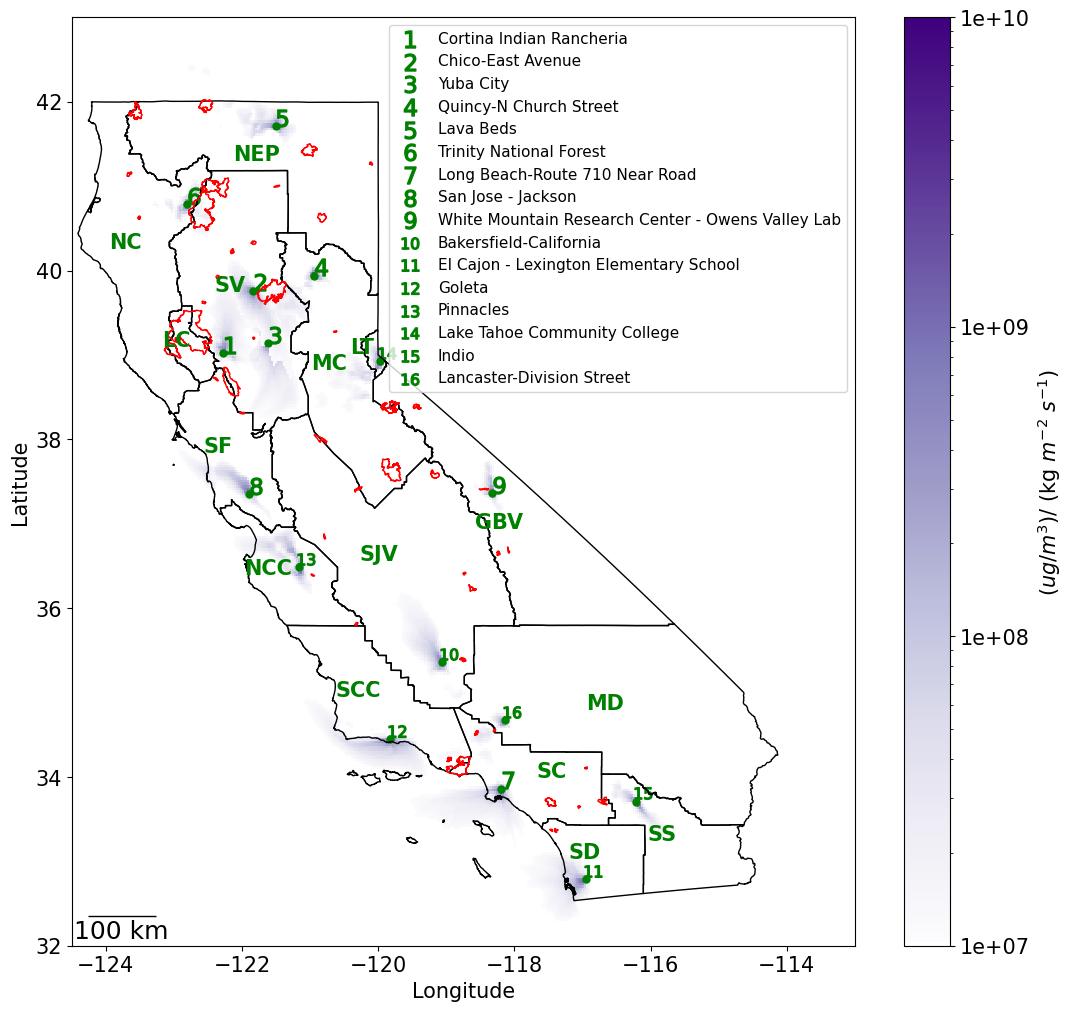

In [35]:
# Plot the air basins with the receptor locations and FINNv2.5 emissions
f, ax = plt.subplots(figsize=(12,10), constrained_layout=True)
color_map='purples_alpha'
# Plot the STILT sensitivities on a log scale $m^{-1}$),
for x in range(0,len(footprint_files)):
    mean_footprint=xr.open_dataset(footprint_path+footprint_files[x])
    # Convert units from ppm umol-1 m2s to ug/m3 kg-1 m2s
    # ppm umol-1 m2s to ppm kg-1 m2s: 10^6 umol/mol * mol/14.1g  *1000 g/kg
    # ppm to ug/m3 is (1000 ug/mg) * (1/24.45 molar vol) * (14.1g/mol)
    mean_footprint= (mean_footprint['Sensitivity']*1e6*1000*1000)/24.45
    # Plot the mean footprint results with purples alpha as color bar 
    im=mean_footprint.plot.imshow(ax=ax, cmap=color_map, norm=mcolors.LogNorm(vmin=1e7,vmax=1e10), add_colorbar=False)

# plot the receptor locations
for y in range(0, len(receptors_table2['Longitude_x'])):
    txt=receptors_table2['Index'][y]
    ax.scatter(receptors_table2['Longitude_x'][y], receptors_table2['Latitude_x'][y], s=25, color='green')
    ax.scatter(receptors_table2['Longitude_x'][y]+0.1, receptors_table2['Latitude_x'][y]+0.1,marker=f'${txt}$', s=150, color='green', label=receptors_table2['Receptor(s)  Names'][y])
ax.legend(markerscale=1, fontsize=11, loc='upper right')

# plot shapefiles of air basins
CA_airbasins_proj.plot(ax=ax, facecolor='none', edgecolor='black', zorder=1)
CA_airbasins_labels.apply(lambda x: ax.annotate(text=x['AB'], xy=x.geometry.centroid.coords[0], ha='left', weight='bold', color='green',size=15) if x['AB']=='SC' 
                        else ax.annotate(text=x['AB'], xy=x.geometry.centroid.coords[0], ha='right', weight='bold', color='green',size=15),
                           axis=1)
# plot the WBSE fire shapefiles
pmarks=[]
for s in range(0, len(shapefile_files)):
    # Read in the shapefile
    shapefile= gpd.read_file(shapefile_path + shapefile_files[s])
    # Reproject the shapefile to the raster crs 
    shapefile= shapefile.to_crs(4326)
    # Plot the shapefile fire perimeter
    shapefile.plot(ax=ax, facecolor="none", edgecolor='red', zorder=1)

#pmarks.append(Patch(facecolor="none", edgecolor='red', label='WBSE Burned Area'))
#handles, _ = ax.get_legend_handles_labels()
#ax.legend(handles=[*handles,*pmarks], loc='upper right', fontsize=17)
# Determine map settings 
xlim = ([-124.5, -113])
ylim = ([32, 43])
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.tick_params(labelsize=15)
ax.set_ylabel('Latitude', fontsize=15)
ax.set_xlabel('Longitude', fontsize=15)
fontprops = fm.FontProperties(size=18)
scalebar = AnchoredSizeBar(ax.transData,
                           1, '100 km', 'lower left', 
                           pad=0.005,
                           color='black',
                           frameon=False,
                           size_vertical=0.005, 
                           fontproperties=fontprops)

ax.add_artist(scalebar)
cax,kw = mpl.colorbar.make_axes([ax])
cbar=plt.colorbar(im, cax=cax, shrink=0.5, pad=0.05, format='%.0e')
cbar.ax.tick_params(labelsize=15)
cbar.set_label("($ug/m^3$)/ (kg $m^{-2}$ $s^{-1}$)",fontsize=15)
plt.show()
f.savefig(directory2 + 'stilt_sensitivity.png', bbox_inches='tight', dpi=900, pad_inches=0.1)
#Sensitivity of Smoke Concentration at Receptor Site to Emissions \n 

### WBSE Fires 

In [36]:
# Read in the fire table with data about individual fires in 2018
fire_table=pd.read_csv(directory2+'Emissions_processing/fire_info_table.csv')

# limit the fires to those that started between 7/1/18 and 9/30/18
fire_table['First Day']=pd.to_datetime(fire_table['First Day'], format="%m/%d/%y")
fire_table['Last Day']=pd.to_datetime(fire_table['Last Day'], format="%m/%d/%y")
fire_table_masked=fire_table[(fire_table['First Day'] < '2018-09-30') & (fire_table['First Day'] >= '2018-07-01') | (fire_table['Last Day'] < '2018-09-30') & (fire_table['Last Day'] >= '2018-07-01')]

# Get the first 10 largest fires by total emissions
fire_table_masked.sort_values(by=['Total Emissions'], ascending=False)[0:10]

,fire,fire_name,longitude,latitude,First Day,Last Day,Peak Emissions Day,Peak Emissions,Total Emissions,Total Area (m^2),Low Severity Area (m^2),Medium Severity Area (m^2),High Severity Area (m^2),Low Severity (%),Medium Severity (%),High Severity (%),Duration
0,CA3924012311020180727,RANCH,-122.768126,39.287252,2018-07-27,2018-09-12,8/4/18,12600000.0,107000000.0,172800090,42198390,72117540,52395660,24.420352,41.734666,30.321547,48
1,CA4065012263020180723,CARR,-122.585737,40.700377,2018-07-23,2018-09-28,7/28/18,9430000.0,66700000.0,93175110,13555170,38597490,39771180,14.548059,41.424679,42.684339,68
3,CA3765211988120180713,FERGUSON,-119.805139,37.631907,2018-07-14,2018-08-12,8/4/18,2630000.0,31300000.0,38801340,6194970,17204400,15316020,15.965866,44.339706,39.472915,30
4,CA4094312242720180905,DELTA,-122.463976,41.000585,2018-09-05,2018-09-29,9/6/18,6400000.0,22400000.0,25788870,3733200,8287110,13677120,14.476012,32.134444,53.034972,25
5,CA3881012220020180630,COUNTY,-122.169893,38.666163,2018-07-01,2018-07-18,7/1/18,7460000.0,16400000.0,37411830,6642000,20093940,9948600,17.753743,53.710123,26.592123,18
6,CA4089112222820180809,HIRZ,-122.276526,40.981092,2018-08-09,2018-09-11,9/2/18,939000.0,14900000.0,18899370,7367040,7721010,3800340,38.980347,40.853267,20.108289,34
7,CA4195612355120180715,NATCHEZ,-123.552722,41.875516,2018-07-18,2018-09-29,8/16/18,616000.0,13200000.0,15686730,4322430,7161210,4183740,27.554691,45.651388,26.670568,74
9,CA3834911992920180801,DONNELL,-119.823801,38.379940,2018-08-03,2018-09-20,8/5/18,1410000.0,10800000.0,14626620,3634110,4417290,6282630,24.845863,30.200347,42.953396,49
10,CA3906012314020180727,RIVER,-123.028460,39.056224,2018-07-27,2018-08-07,7/28/18,2100000.0,10300000.0,19795680,4201740,10260360,5119740,21.225540,51.831309,25.862916,12
11,CA4139512105720180815,STONE,-121.016768,41.423611,2018-08-16,2018-08-26,8/18/18,2070000.0,10200000.0,15966450,10535490,3713940,1512360,65.985175,23.260900,9.472112,11


In [37]:
fire_table_masked.to_csv(directory2+ 'Emissions_processing/top_ten_fires.csv')

In [38]:
# Get the MTBS shapefiles 
shapefile_path = directory2 + 'mtbs/2018/'
shapefile_files = [s for s in listdir(shapefile_path) if isfile(join(shapefile_path, s)) & s.endswith("bndy.shp")]

In [39]:
# MTBS identifier for the top 10 fires
list_names=['ca3924012311020180727', 'ca4065012263020180723', 'ca3765211988120180713', 'ca4094312242720180905', 'ca3881012220020180630',
'ca4089112222820180809', 'ca4195612355120180715', 'ca3834911992920180801', 'ca3906012314020180727', 'ca4139512105720180815']

In [40]:
# Get the names of top 10 fires
fire_names_list=(fire_table_masked.sort_values(by=['Total Emissions'], ascending=False).reset_index()[0:11]['fire_name'])

In [41]:
colors=['#a6cee3', '#1f78b4', '#a0dc00', '#33a02c', '#fb9a99', '#e31a1c', '#fdbf6f', '#ffd700', '#cab2d6',
        '#6a3d9a']

In [42]:
# Get the WBSE shapefiles
shapefile_wbse_path=directory2+'daily_grid_CA/'
shapefiles_wbse=[s for s in listdir(shapefile_wbse_path) if isfile(join(shapefile_wbse_path, s)) & s.endswith(".shp")]

### PM2.5 Concentrations from Individual Fires

In [43]:
# Load the individual fire files
individ_files = [f for f in listdir(mypath) if isfile(join(mypath, f)) & f.endswith("individfires_conc_all2018days_72.csv")]

In [44]:
# Load the total concentrations fire files
total_files = [t for t in listdir(mypath) if isfile(join(mypath, t)) & t.endswith("wildfire_conc_all2018days_72.csv")]

In [45]:
# Create dictionary with each csv file and make dataframe for individual fire concentration results 
d_individ = {}
receptor_names=[]
for x in range(0, len(individ_files)): 
    text = individ_files[x].split("_")
    receptor_names.append(receptor_locations['SiteName'][np.around(receptor_locations['Longitude_x'],decimals=5).astype(str)==text[0]]) 
    recept_name_new= receptor_names[x].iloc[0]
    d_individ['{0}'.format(recept_name_new)]= pd.read_csv(mypath + individ_files[x])
    data = pd.DataFrame(d_individ['{0}'.format(recept_name_new)])
    data=data[['Time_PST','CA3924012311020180727.tif', 'CA4065012263020180723.tif', 'CA3765211988120180713.tif', 'CA4094312242720180905.tif', 'CA3881012220020180630.tif',
    'CA4089112222820180809.tif', 'CA4195612355120180715.tif', 'CA3834911992920180801.tif', 'CA3906012314020180727.tif', 'CA4139512105720180815.tif']]
    d_individ['{0}'.format(recept_name_new)]=data

In [46]:
# Create dictionary with each csv file and make dataframe for total fire concentration results 
d_total= {}
receptor_names=[]
for x in range(0, len(total_files)): 
    text = total_files[x].split("_")
    receptor_names.append(receptor_locations['SiteName'][np.around(receptor_locations['Longitude_x'],decimals=5).astype(str)==text[0]]) 
    recept_name_new= receptor_names[x].iloc[0]
    d_total['{0}'.format(recept_name_new)]= pd.read_csv(mypath + total_files[x])

In [47]:
# Iterate through each receptor and calculate mean daily fire PM2.5 from individual fires and total fire concentrations
d_mean={}
mean_WBSE_all=pd.DataFrame(columns=['receptor','mean_WBSE'])
i=0
for key in list(d_total.keys()):
    df_individ = d_individ[key]
    df_total=d_total[key]
    # Create dataframe that sums the PM2.5 contributions from each fire for 7/1-9/30
    mean_individ = pd.DataFrame(df_individ.drop('Time_PST', axis=1).mean(axis=0), columns=['Mean PM2.5'])
    # Add to dataframe for total WBSE PM2.5 concentrations at each receptor
    mean_WBSE=df_total['PM25_WBSE'].mean()
    mean_WBSE_all.loc[i]=[key, mean_WBSE]
    i+=1
    # Join the fire IDs with fire names 
    mean_individ.index = mean_individ.index.map(lambda x: str(x)[:-4])
    fire_names= fire_table_masked[['fire', 'fire_name']][0:10]
    fire_names.index = fire_names["fire"]
    mean_individ=fire_names.join(mean_individ, how='inner')
    # Save each receptor's dataframe in dictionary 
    d_mean[key]=mean_individ

In [48]:
# Merge the total WBSE PM2.5 concentration with receptor locations df 
receptors_table3=receptors_table2.merge(mean_WBSE_all, left_on='Receptor(s)  Names', right_on='receptor')

In [49]:
# Iterate through each receptor and create dictionary entry for each day over 35 ug/m3
d_fire_days={}
for key in list(d_individ.keys()):
    # Create dataframe for the fire ID and number of days over 35ug/m3
    sum_fire_days=pd.DataFrame(columns=['fire_id','days_above_35'])
    # get receptor data
    df= d_individ[key]
    # Iterate over column names
    i=0
    for column in df.columns[1:]:
        # for each column representing a fire, get the values above 35
        df_column=df[df[column] >=35]
        # Count the number of values above 35 ug/m3
        df_count=df_column[column].count()
        sum_fire_days.loc[i]=[column, df_count]
        i+=1
    # Join the fire IDs with fire names 
    sum_fire_days['fire_id'] = sum_fire_days['fire_id'].map(lambda x: str(x)[:-4])
    fire_names= fire_table_masked[['fire', 'fire_name']][0:10]
    sum_fire_days=fire_names.merge(sum_fire_days, left_on='fire', right_on='fire_id', how='inner')
    d_fire_days[key]=sum_fire_days

In [50]:
# Create dataframe for the receptor and number of days over 35ug/m3
d_WBSE_days = pd.DataFrame(columns=['receptor','days_above_35'])
d_WBSE_dates = pd.DataFrame(columns=['receptor', 'dates_PM25_over_35'])
i=0
j=0
for key in list(d_individ.keys()):
    df=d_total[key]
    df_receptor=df[df['PM25_WBSE']>=35].reset_index()
    df_receptor['Time_PST']= pd.to_datetime(df_receptor['Time_PST'], unit='D', origin=pd.Timestamp('1970-01-01'))
    if len(df_receptor['PM25_WBSE']) >0:
        for x in range(0, len(df_receptor['PM25_WBSE'])):
            # get the dates when the WBSE fire PM2.5 is over 35ug/m3
            d_WBSE_dates.loc[j]= [key, df_receptor['Time_PST'][x]]
            j+=1
    df_count=df_receptor['PM25_WBSE'].count()
    d_WBSE_days.loc[i]=[key, df_count]
    i+=1

In [51]:
# Get the number of fires contributing to days over 35ug/m3 for each receptor 
d_num_fires={}
for receptor in list(d_total.keys()):
    if receptor in (d_WBSE_dates['receptor'].unique()):
        dates=d_WBSE_dates['dates_PM25_over_35'][d_WBSE_dates['receptor']==receptor]
        individ_fires=d_individ[receptor]
        individ_fires['Time_PST']=pd.to_datetime(individ_fires['Time_PST'])
        individ_fires = individ_fires.loc[individ_fires['Time_PST'].isin(dates)]
        variable_names=individ_fires.columns[1:]
        num_fires=individ_fires[variable_names].astype(bool).sum(axis=1)
        num_fires= num_fires.value_counts().rename_axis('num_fires')
        num_fires_new=num_fires.to_frame().sort_values(by='num_fires', ascending=True)
        d_num_fires[receptor]=num_fires_new.reset_index()
    else:
        d_num_fires[receptor]=pd.DataFrame(data=np.zeros((1,2)),columns=['num_fires','count'])

In [52]:
# Merge the total number of days above 35ug/m3 with receptor locations df 
receptors_table3=receptors_table3.merge(d_WBSE_days, left_on='Receptor(s)  Names', right_on='receptor')

/var/folders/bt/zz9p33b12m55w8szgpmyprmr0000gn/T/ipykernel_50423/2908830395.py:60: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/bt/zz9p33b12m55w8szgpmyprmr0000gn/T/ipykernel_50423/2908830395.py:61: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



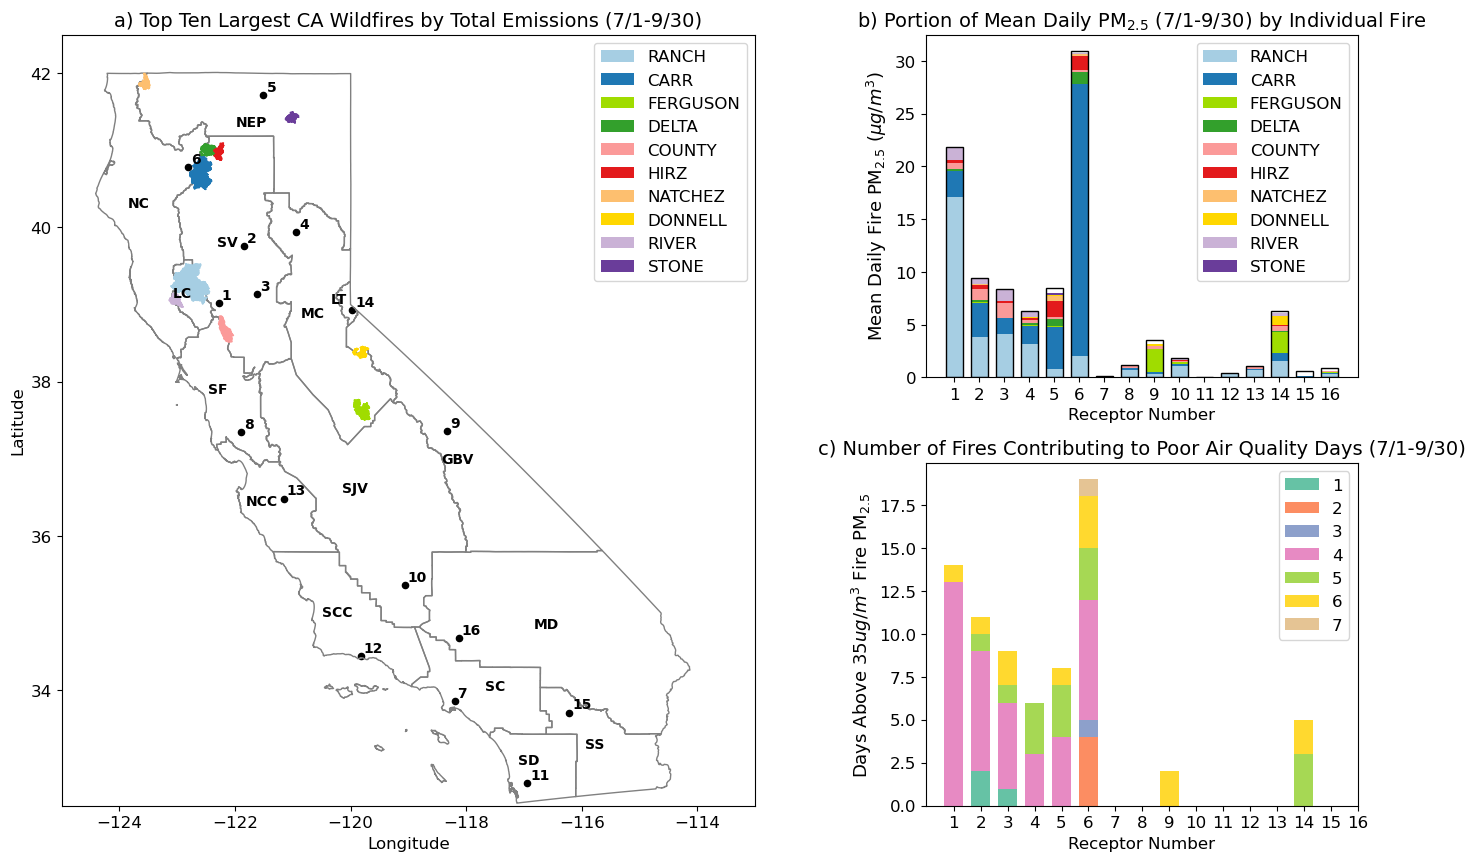

In [65]:
# Plot all of the mtbs boundaries for selected fires (top 15 in total emissions)
fig= plt.figure(figsize=(14,8.5),constrained_layout=True)
# add grid specifications
gs = fig.add_gridspec(2, 3)
# open axes/subplots
axs = []
axs.append( fig.add_subplot(gs[:,0:2]) ) # large subplot (2 rows, 2 columns)
axs.append( fig.add_subplot(gs[0,2]) )   # small subplot (1st row, 3rd column)
axs.append( fig.add_subplot(gs[1,2]) )   # small subplot (2nd row, 3rd column)


# plot the receptor locations
axs[0].scatter(receptors_table3['Longitude_x'], receptors_table3['Latitude_x'], s=20, color='black')
n= receptors_table3['Index']
for i, txt in enumerate(n):
    axs[0].annotate(txt, (receptors_table3['Longitude_x'][i]+0.05, receptors_table3['Latitude_x'][i]+0.05), weight='bold', color='black',size=10)

# plot shapefiles of air basins
CA_airbasins_proj.plot(ax=axs[0], facecolor='none', edgecolor='gray', zorder=1)
CA_airbasins_labels.apply(lambda x: axs[0].annotate(text=x['AB'], xy=x.geometry.centroid.coords[0], ha='left', weight='bold', color='black',size=10) if x['AB']=='SC' 
                        else axs[0].annotate(text=x['AB'], xy=x.geometry.centroid.coords[0], ha='right', weight='bold', color='black',size=10),
                           axis=1);

# Plot the california boundary shapefile
#ca_boundary.plot(ax=ax, facecolor='none', edgecolor='black', zorder=1)

# MTBS Fires 
pmarks = []
for x in range(0, 10):
    # Find the file that matches the current fire MTBS code name
    shapefile_file=[s for s in listdir(shapefile_path) if isfile(join(shapefile_path, s)) & s.endswith("bndy.shp") & s.startswith(list_names[x])][0]
    # Read the input shapefile
    input_shapefile = shapefile_path + shapefile_file
    shapefile = gpd.read_file(input_shapefile)
    # Reproject the shapefile to the raster crs 
    shapefile= shapefile.to_crs(4326)
    # Plot the shapefile fire perimeter
    shapefile_plot=shapefile.plot(ax=axs[0], facecolor=colors[x], edgecolor=colors[x], hatch= "///", zorder=1)
    pmarks.append(Patch(facecolor=colors[x], label=fire_names_list[x]))

handles, _ = axs[0].get_legend_handles_labels()
axs[0].legend(handles=[*handles,*pmarks], loc='upper right', fontsize=12)
# map settings
axs[0].set_title("a) Top Ten Largest CA Wildfires by Total Emissions (7/1-9/30)", fontsize=14)
axs[0].set_ylabel('Latitude', fontsize=12)
axs[0].set_xlabel('Longitude', fontsize=12)
xlim = ([-125, -113])
ylim = ([32.5, 42.5])
axs[0].tick_params(labelsize=12)
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)

# Bar plot representing the portion of total PM2.5 concentrations in the fire season
width = 0.7
for y in range(0,len(list(d_mean.keys()))):
    recept_name= receptors_table3['Receptor(s)  Names'][y]
    data= pd.DataFrame(d_mean['{0}'.format(recept_name)])
    bottom=0
    for x in range(0, data.shape[0]):
        p = axs[1].bar(y+1, data['Mean PM2.5'][x], width, label=data['fire_name'][x], color=colors[x], bottom=bottom)
        bottom += data['Mean PM2.5'][x]
        #point = Line2D([0], [0], label='Total Mean Daily PM$_{2.5}$', marker='s', markersize=9, 
        #markeredgecolor='k', markerfacecolor='white', linestyle='')
axs[1].bar(receptors_table3['Index'], receptors_table3['mean_WBSE'], align='center', width=0.7, edgecolor='black', color='none')
axs[1].legend(handles=[*handles,*pmarks], loc='upper right', fontsize=12)
axs[1].set_title("b) Portion of Mean Daily PM$_{2.5}$ (7/1-9/30) by Individual Fire", fontsize=14)
axs[1].set_xlabel('Receptor Number', fontsize=12)
axs[1].set_ylabel('Mean Daily Fire PM$_{2.5}$ ($µg/m^3$)', fontsize=13)
axs[1].set_xticks(range(1,17))
axs[1].tick_params(labelsize=12)

# Bar plot representing the number of fires contributing to poor air quality days
bar_colors = {1:'#66c2a5', 2: '#fc8d62', 3: '#8da0cb', 4: '#e78ac3', 5: '#a6d854', 6:'#ffd92f', 7:'#e5c494'}
width = 0.7
for y in range(0,len(list(d_num_fires.keys()))):
    recept_name= receptors_table3['Receptor(s)  Names'][y]
    data= pd.DataFrame(d_num_fires['{0}'.format(recept_name)])
    bottom=0
    for x in range(0, data.shape[0]):
        if data['num_fires'].sum() >0:
            p = axs[2].bar(y+1, data['count'][x], width, label=data['num_fires'][x], color=bar_colors[data['num_fires'][x]], bottom=bottom)
            bottom += data['count'][x]
pmarks=[]
for y in range(0, len(list(bar_colors.keys()))):
    pmarks.append(Patch(facecolor=list(bar_colors.values())[y], label=list(bar_colors.keys())[y]))
axs[2].legend(handles=[*pmarks], loc='upper right', fontsize=12)
axs[2].set_title("c) Number of Fires Contributing to Poor Air Quality Days (7/1-9/30)", fontsize=14)
axs[2].set_xlabel('Receptor Number', fontsize=12)
axs[2].set_ylabel('Days Above 35$ug/m^3$ Fire PM$_{2.5}$', fontsize=13)
axs[2].set_xticks(range(1,17))
axs[2].tick_params(labelsize=12)

plt.show()
fig.savefig(mypath + '72hr_figures/figure5_fires.pdf', bbox_inches='tight',pad_inches=0.1)

In [199]:
# Make pie charts of the contributions of individual fires to PM2.5 concentrations
# let colors be a list of unique colors, at least one for each name
# MTBS Fires 
colors=['#a6cee3', '#1f78b4', '#a0dc00', '#33a02c', '#fb9a99', '#e31a1c', '#fdbf6f', '#ffd700', '#cab2d6',
        '#6a3d9a']
pmarks = []
for x in range(0, 10):
    # Find the file that matches the current fire MTBS code name
    shapefile_file=[s for s in listdir(shapefile_path) if isfile(join(shapefile_path, s)) & s.endswith("bndy.shp") & s.startswith(list_names[x])][0]
    # Read the input shapefile
    input_shapefile = shapefile_path + shapefile_file
    shapefile = gpd.read_file(input_shapefile)
    pmarks.append(Patch(facecolor=colors[x], label=fire_names_list[x]))

handles, _ = axs[0].get_legend_handles_labels()

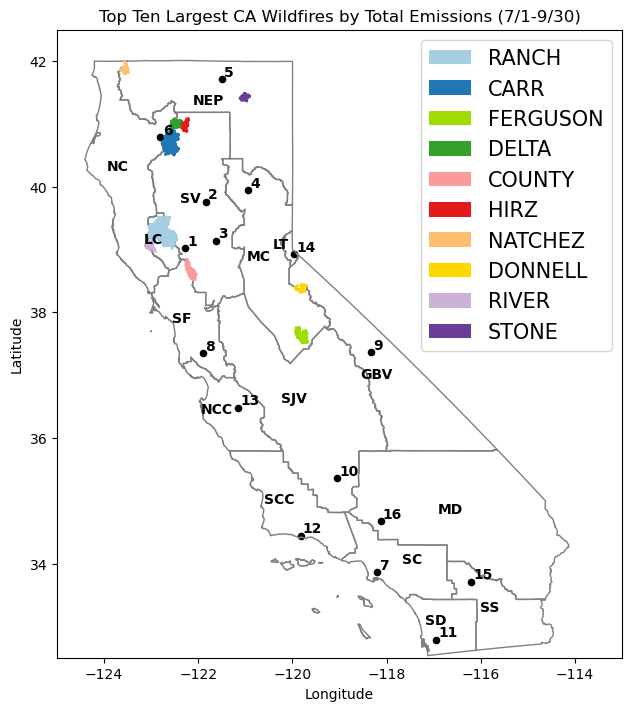

In [248]:
# Plot all of the mtbs boundaries for selected fires (top 15 in total emissions)
fig, ax= plt.subplots(figsize=(11,7),constrained_layout=True)
# plot the receptor locations
ax.scatter(receptors_table3['Longitude_x'], receptors_table3['Latitude_x'], s=20, color='black')
n= receptors_table3['Index']
for i, txt in enumerate(n):
    plt.annotate(txt, (receptors_table3['Longitude_x'][i]+0.05, receptors_table3['Latitude_x'][i]+0.05), weight='bold', color='black',size=10)

# plot shapefiles of air basins
CA_airbasins_proj.plot(ax=ax, facecolor='none', edgecolor='gray', zorder=1)
CA_airbasins_labels.apply(lambda x: ax.annotate(text=x['AB'], xy=x.geometry.centroid.coords[0], ha='left', weight='bold', color='black',size=10) if x['AB']=='SC' 
                        else ax.annotate(text=x['AB'], xy=x.geometry.centroid.coords[0], ha='right', weight='bold', color='black',size=10),
                           axis=1);
# MTBS Fires 
pmarks = []
for x in range(0, 10):
    # Find the file that matches the current fire MTBS code name
    shapefile_file=[s for s in listdir(shapefile_path) if isfile(join(shapefile_path, s)) & s.endswith("bndy.shp") & s.startswith(list_names[x])][0]
    # Read the input shapefile
    input_shapefile = shapefile_path + shapefile_file
    shapefile = gpd.read_file(input_shapefile)
    # Reproject the shapefile to the raster crs 
    shapefile= shapefile.to_crs(4326)
    # Plot the shapefile fire perimeter
    shapefile_plot=shapefile.plot(ax=ax, facecolor=colors[x], edgecolor=colors[x], hatch= "///", zorder=1)
    pmarks.append(Patch(facecolor=colors[x], label=fire_names_list[x]))

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=[*handles,*pmarks], loc='upper right', fontsize=15)
# map settings
ax.set_title("Top Ten Largest CA Wildfires by Total Emissions (7/1-9/30)", fontsize=12)
ax.set_ylabel('Latitude', fontsize=10)
ax.set_xlabel('Longitude', fontsize=10)
xlim = ([-125, -113])
ylim = ([32.5, 42.5])
ax.tick_params(labelsize=10)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.show()
fig.savefig(mypath + '72hr_figures/abstract_ca_map.pdf', bbox_inches='tight', pad_inches=0.1)

/var/folders/bt/zz9p33b12m55w8szgpmyprmr0000gn/T/ipykernel_15821/1939377593.py:11: UserWarning:

The figure layout has changed to tight



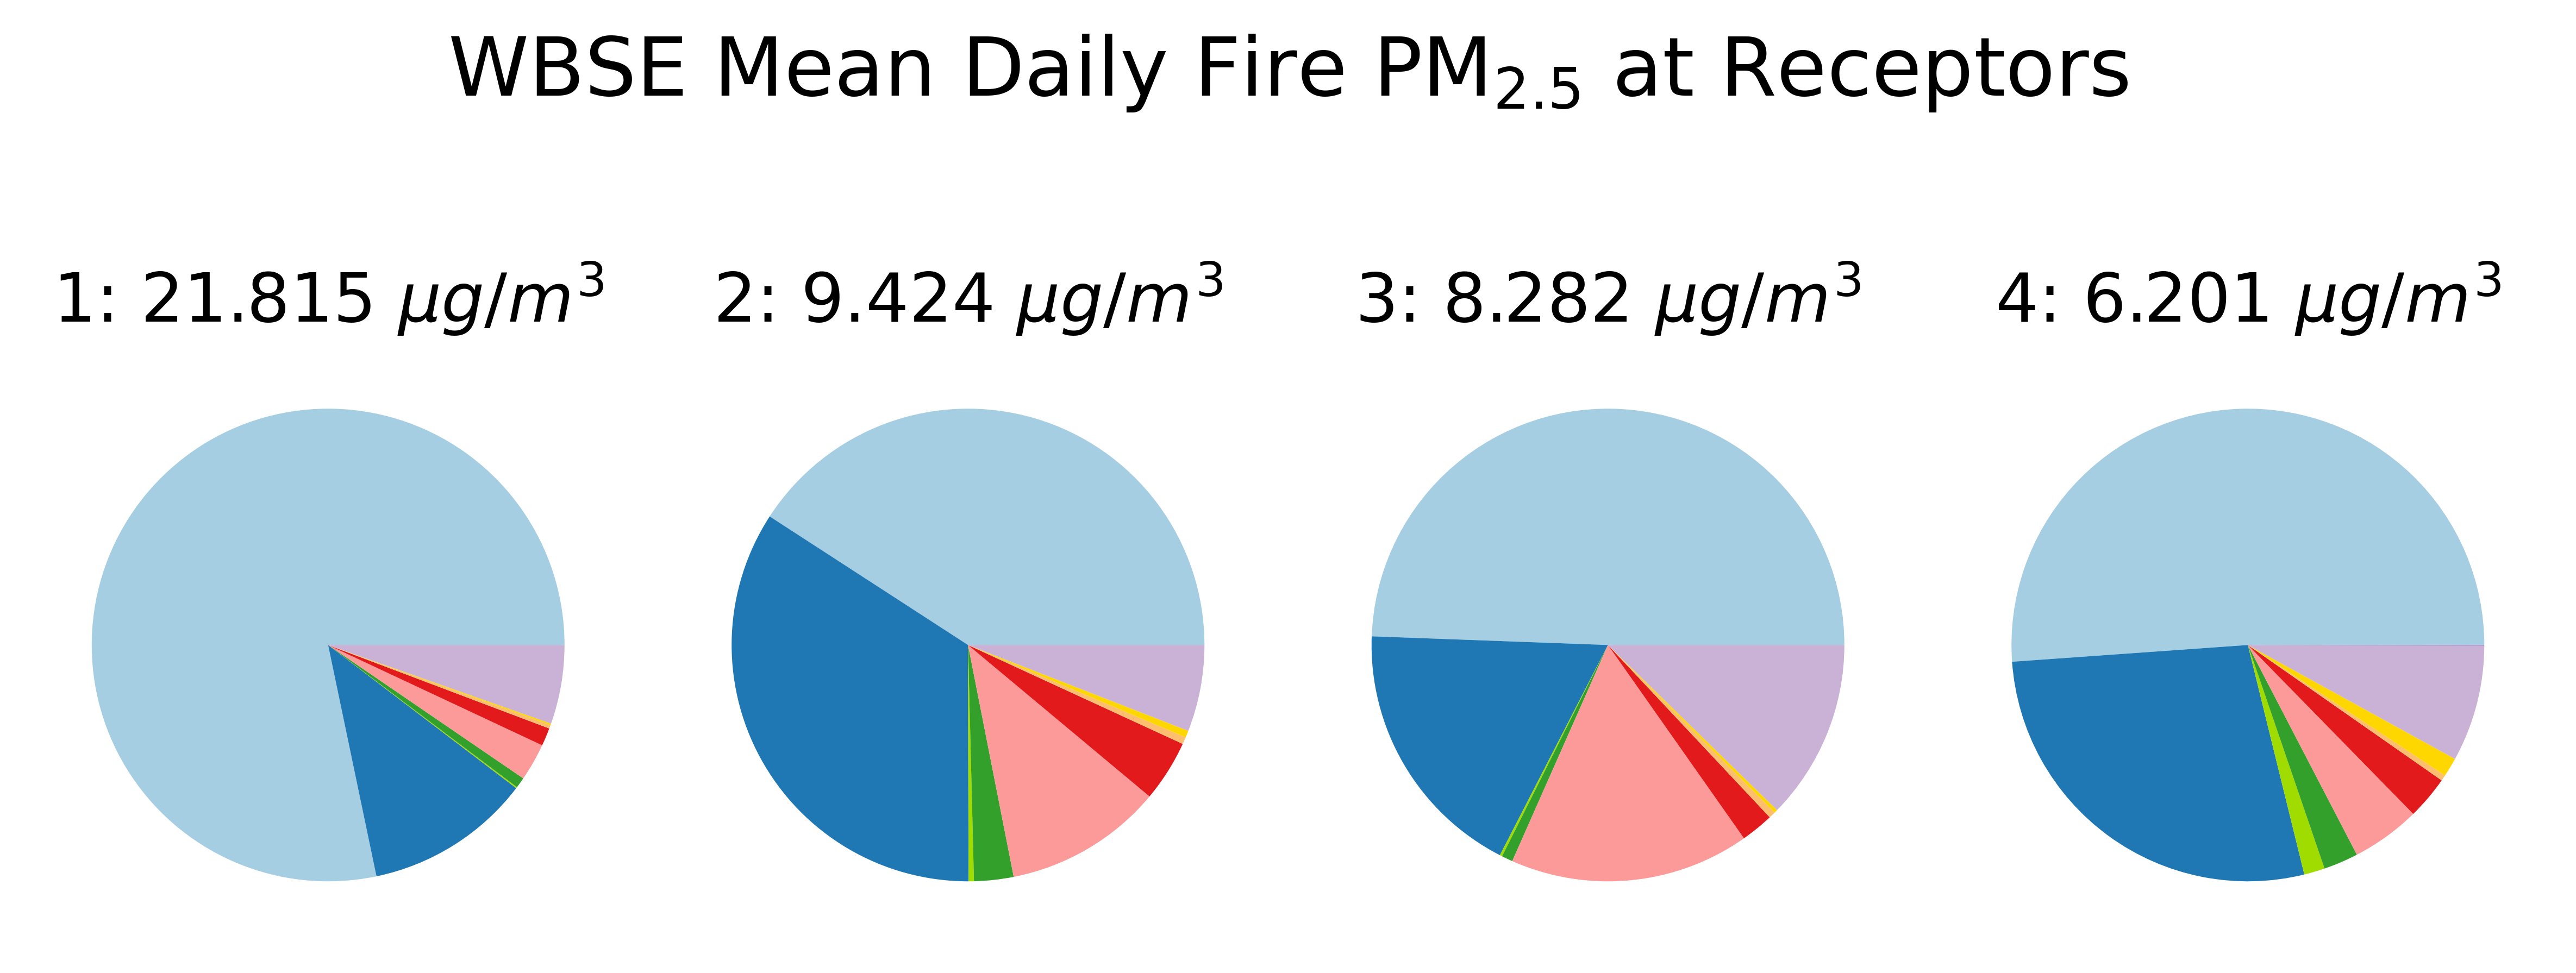

In [254]:
fig, axs = plt.subplots(1, 4, figsize=(8, 3.5), dpi=600, facecolor='w', edgecolor='k', constrained_layout=True)
count=0
for y in range(0,4):
    recept_name0= receptors_table3['Receptor(s)  Names'][y]
    data= pd.DataFrame(d_mean['{0}'.format(recept_name0)])
    axs[count].pie(data['Mean PM2.5'], labels=data['fire_name'], labeldistance=None, colors=colors)
    axs[count].set_title(str(y+1)+': '+ str(sum(np.round(data['Mean PM2.5'],3)))+ ' $µg/m^3$', fontsize=15)
    count+=1
#axs[0].legend(handles=[*handles,*pmarks],bbox_to_anchor=(0.2, 1.1), loc='lower left')
fig.suptitle('WBSE Mean Daily Fire PM$_{2.5}$ at Receptors', fontsize=18)
plt.tight_layout()
plt.show()
fig.savefig(mypath + '72hr_figures/abstract_graphics1.pdf', bbox_inches='tight', pad_inches=0.1)

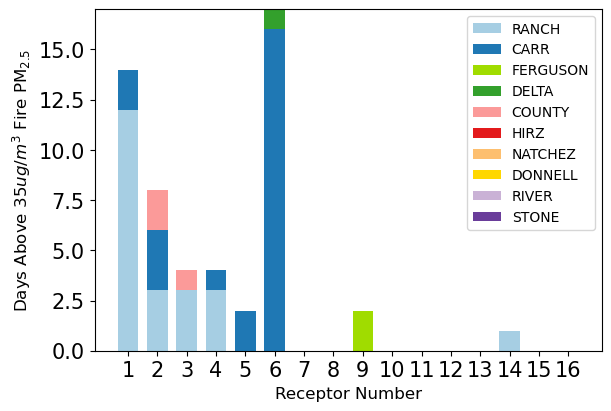

In [138]:
# Supplemental figure for fires that account to poor air quality days on their own 
fig, axs= plt.subplots(figsize=(6,4),constrained_layout=True)
width = 0.7
for y in range(0,len(list(d_fire_days.keys()))):
    recept_name= receptors_table3['Receptor(s)  Names'][y]
    data= pd.DataFrame(d_fire_days['{0}'.format(recept_name)])
    bottom=0
    for x in range(0, data.shape[0]):
        p = axs.bar(y+1, data['days_above_35'][x], width, label=data['fire_name'][x], color=colors[x], bottom=bottom)
        bottom += data['days_above_35'][x]
pmarks=[]
for y in range(0, len(colors)):
    pmarks.append(Patch(facecolor=colors[y], label=fire_names_list[y]))
axs.legend(handles=[*pmarks], loc='upper right', fontsize=10)
#axs.set_title("Days when fires account for poor air quality on their own", fontsize=15)
axs.set_xlabel('Receptor Number', fontsize=12)
axs.set_ylabel('Days Above 35$ug/m^3$ Fire PM$_{2.5}$', fontsize=12)
axs.set_xticks(range(1,17))
axs.tick_params(labelsize=15)
fig.savefig(mypath + '72hr_figures/supp_fig_firedays.pdf', bbox_inches='tight', pad_inches=0.1)

In [31]:
d_fire_days

{'Pinnacles':                     fire fire_name                fire_id  days_above_35
 0  CA3924012311020180727     RANCH  CA3924012311020180727              0
 1  CA4065012263020180723      CARR  CA4065012263020180723              0
 2  CA3765211988120180713  FERGUSON  CA3765211988120180713              0
 3  CA4094312242720180905     DELTA  CA4094312242720180905              0
 4  CA3881012220020180630    COUNTY  CA3881012220020180630              0
 5  CA4089112222820180809      HIRZ  CA4089112222820180809              0
 6  CA4195612355120180715   NATCHEZ  CA4195612355120180715              0
 7  CA3834911992920180801   DONNELL  CA3834911992920180801              0
 8  CA3906012314020180727     RIVER  CA3906012314020180727              0
 9  CA4139512105720180815     STONE  CA4139512105720180815              0,
 'Goleta':                     fire fire_name                fire_id  days_above_35
 0  CA3924012311020180727     RANCH  CA3924012311020180727              0
 1  CA40650122